<a href="https://colab.research.google.com/github/AmatHub21/codingan_kelompok_mechineLearning/blob/main/codingan_kelompok_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
student_performance = fetch_ucirepo(id=320)

# data (as pandas dataframes)
X = student_performance.data.features
y = student_performance.data.targets

# metadata
print(student_performance.metadata)

# variable information
print(student_performance.variables)


{'uci_id': 320, 'name': 'Student Performance', 'repository_url': 'https://archive.ics.uci.edu/dataset/320/student+performance', 'data_url': 'https://archive.ics.uci.edu/static/public/320/data.csv', 'abstract': 'Predict student performance in secondary education (high school). ', 'area': 'Social Science', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 649, 'num_features': 30, 'feature_types': ['Integer'], 'demographics': ['Sex', 'Age', 'Other', 'Education Level', 'Occupation'], 'target_col': ['G1', 'G2', 'G3'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Fri Jan 05 2024', 'dataset_doi': '10.24432/C5TG7T', 'creators': ['Paulo Cortez'], 'intro_paper': {'ID': 360, 'type': 'NATIVE', 'title': 'Using data mining to predict secondary school student performance', 'authors': 'P. Cortez, A. M. G. Silva', 'venue': 'Proceedings of 5th Annual Future Business Technolo

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving student-por[1].csv to student-por[1].csv


In [ ]:
 import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
df = pd.read_csv("student-por[1].csv", sep=";")

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [ ]:
print("Jumlah baris dan kolom:", df.shape)

Jumlah baris dan kolom: (649, 33)


In [ ]:
df["status"] = df["G3"].apply(
    lambda x: "Lulus" if x >= 10 else "Tidak Lulus"
)

df[["G3", "status"]].head(10)

,G3,status
0,11,Lulus
1,11,Lulus
2,12,Lulus
3,14,Lulus
4,13,Lulus
5,13,Lulus
6,13,Lulus
7,13,Lulus
8,17,Lulus
9,13,Lulus


In [ ]:
print(df["status"].value_counts())

status
Lulus          549
Tidak Lulus    100
Name: count, dtype: int64


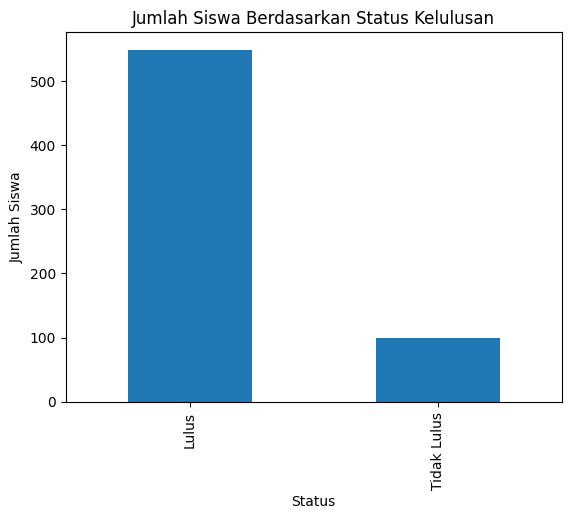

In [ ]:
df["status"].value_counts().plot(kind="bar")

plt.title("Jumlah Siswa Berdasarkan Status Kelulusan")
plt.xlabel("Status")
plt.ylabel("Jumlah Siswa")
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data training:", X_train.shape)
print("Data testing :", X_test.shape)

X = df.drop(columns=["G3", "status"])
y = df["status"]

Data training: (519, 32)
Data testing : (130, 32)


In [ ]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns

print("Kolom kategorikal:")
print(categorical_features.tolist())

print("\nKolom numerik:")
print(numerical_features.tolist())

Kolom kategorikal:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Kolom numerik:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [ ]:
model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", SGDClassifier(
        loss="log_loss",
        random_state=42,
        max_iter=1000,
        tol=1e-3
    ))
])

In [ ]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object'))])),
                ('classifier',
                 SGDClassifier(loss='log_loss', random_state=42))])

In [ ]:
y_pred = model.predict(X_test)

print(y_pred[:10])

['Lulus' 'Lulus' 'Lulus' 'Lulus' 'Lulus' 'Lulus' 'Lulus' 'Tidak Lulus'
 'Tidak Lulus' 'Lulus']


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Akurasi Model:", accuracy)
print("Akurasi (%):", accuracy * 100)

Akurasi Model: 0.9230769230769231
Akurasi (%): 92.3076923076923


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Akurasi Model:", accuracy)
print("Akurasi (%):", accuracy * 100)

Akurasi Model: 0.9230769230769231
Akurasi (%): 92.3076923076923


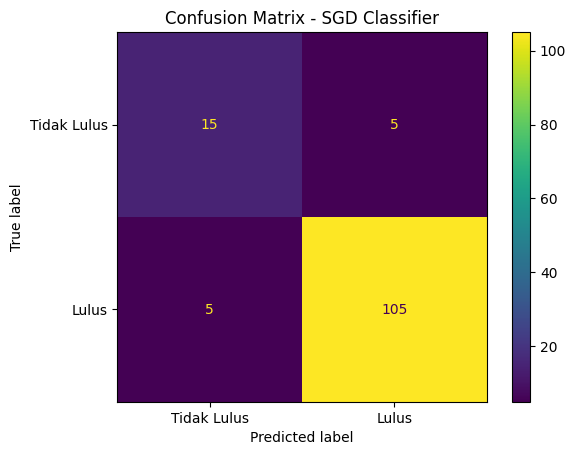

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Tidak Lulus", "Lulus"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Tidak Lulus", "Lulus"]
)

disp.plot()
plt.title("Confusion Matrix - SGD Classifier")
plt.show()

In [ ]:
hasil = pd.DataFrame({
    "Aktual": y_test.values,
    "Prediksi": y_pred
})

hasil.head(20)

,Aktual,Prediksi
0,Lulus,Lulus
1,Lulus,Lulus
2,Lulus,Lulus
3,Lulus,Lulus
4,Lulus,Lulus
5,Lulus,Lulus
6,Lulus,Lulus
7,Tidak Lulus,Tidak Lulus
8,Tidak Lulus,Tidak Lulus
9,Lulus,Lulus


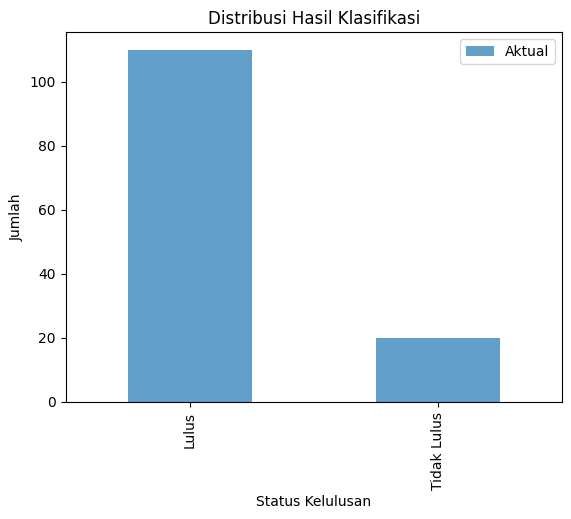

In [ ]:
hasil["Aktual"].value_counts().plot(
    kind="bar",
    alpha=0.7,
    label="Aktual"
)

plt.title("Distribusi Hasil Klasifikasi")
plt.xlabel("Status Kelulusan")
plt.ylabel("Jumlah")
plt.legend()
plt.show()